In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_parquet("C:/Github/NTR-Arogyaseva-analysis/data/processed/ntrarogyaseva.parquet")

In [97]:
df["surgery"] = df["surgery"].str.replace("medical", "").str.replace("management", "")

In [98]:
data = df.groupby("surgery")["mortality"].agg(["count", "mean"]).reset_index().sort_values(by="mean", ascending=False)
data["label"] = ((data["count"]>10) & (data["mean"]>0.1)).astype(int)

In [100]:
# separar features y target
X = data["surgery"].copy()
y = data["label"].copy()

# split train + test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(len(X_train), len(X_test))

735 184


In [101]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=10000,
        stop_words="english"
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

In [102]:
pipeline.fit(X, y)

,steps,"[('tfidf', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [103]:
y_pred = pipeline.predict(X)

acc = accuracy_score(y, y_pred)

print(f"Accuracy (test): {acc:.4f}")
print("\nClassification Report:\n", classification_report(y, y_pred))

Accuracy (test): 0.9543

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.97       853
           1       0.61      1.00      0.76        66

    accuracy                           0.95       919
   macro avg       0.81      0.98      0.87       919
weighted avg       0.97      0.95      0.96       919



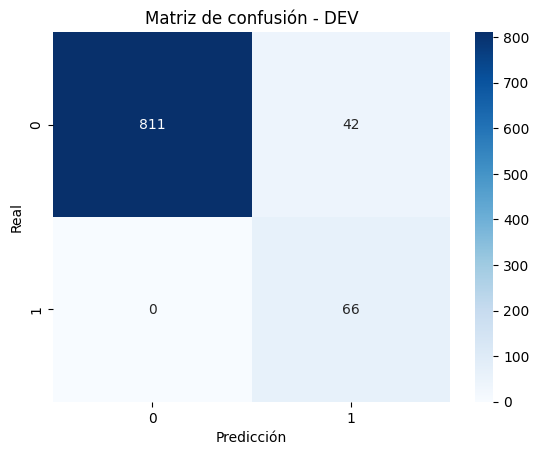

In [104]:
cm = confusion_matrix(y, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - DEV")
plt.show()

In [105]:
feature_names = pipeline.named_steps["tfidf"].get_feature_names_out()
coefs = pipeline.named_steps["clf"].coef_[0]

top_pos_idx = coefs.argsort()[-20:][::-1]
top_neg_idx = coefs.argsort()[:20]

print("Top positivo:")
print([feature_names[i] for i in top_pos_idx])

print("\nTop negativo:")
print([feature_names[i] for i in top_neg_idx])

Top positivo:
['burns', 'ards', 'acute', 'pericardiectomy', 'aki', 'tapvc', 'cirrhosis', 'tracheostomy', 'respiratory', 'shock', 'aneurysm', 'requiring', 'septic', 'neuro', 'subtentorial', 'ulcers', 'intra', 'mixed', 'ventilatory', 'meningitis']

Top negativo:
['malignant', 'conditions', 'chemotherapy', 'procedure', 'cancer', 'bypass', 'stage', 'injuries', 'laproscopic', 'mesh', 'laparoscopic', 'fistula', 'surgery', 'mild', 'reconstruction', 'tumors', 'cyst', 'bone', 'total', 'vascular']


In [106]:
coefs_df = pd.Series(coefs, index=feature_names).sort_values(ascending=False)
coefs_df[coefs_df > 0].index.tolist()

['burns',
 'ards',
 'acute',
 'aki',
 'pericardiectomy',
 'tapvc',
 'cirrhosis',
 'tracheostomy',
 'respiratory',
 'shock',
 'aneurysm',
 'requiring',
 'septic',
 'neuro',
 'subtentorial',
 'ulcers',
 'intra',
 'mixed',
 'ventilatory',
 'meningitis',
 'severe',
 'ventriculostomy',
 'failure',
 'evacuation',
 'baby',
 'encephalitis',
 'conservative',
 'tb',
 'term',
 'switch',
 'trauma',
 'neuroinfections',
 'temporary',
 'clipping',
 'bleeding',
 'cranial',
 'craniectomy',
 'compressive',
 'intestinal',
 'arota',
 'coarctation',
 'hepato',
 'atresia',
 'diaphragmatic',
 'endoscopic',
 'evd',
 '60',
 'grafting',
 'pacemaker',
 'support',
 '50',
 'atresias',
 'tga',
 'drainage',
 'mi',
 'blood',
 'poisioning',
 'organ',
 'multi',
 'pulmonary',
 'ventilation',
 'ia',
 'bronchopneumon',
 'traumatic',
 'care',
 'ventricular',
 'tof',
 'shunts',
 'bacterial',
 'hematoma',
 'patients',
 '40',
 'subdural',
 'induction',
 'implantation',
 'haematoma',
 'craniotomy',
 'phase',
 '30',
 'myeloid',

In [107]:
import re

risk_flags = {
    "critical_organ_failure": [
        "ards", "acute", "aki", "failure", "hepatic",
        "encephalopathy", "coma", "metabolic",
        "multi", "organ", "cirrhosis"
    ],

    "hemodynamic_instability": [
        "shock", "cardiogenic", "septic",
        "septicemia", "septi", "cemia",
        "dic", "d65"
    ],

    "mechanical_life_support": [
        "ventilation", "ventilator", "ventilatory",
        "ventilated", "mechanical",
        "cpap", "hfo", "icu",
        "intensive", "support",
        "supportive", "iabp", "pump"
    ],

    "severe_infection": [
        "meningitis", "encephalitis",
        "meningoencephalitis", "pyogenic",
        "bacterial", "infective",
        "fungal", "neuroinfections"
    ],

    "hemorrhage_or_stroke": [
        "hematoma", "haematoma",
        "hemorrhagic", "bleeding", "bleed",
        "subdural", "cerebral", "brain",
        "stroke", "strokes",
        "i61", "i62", "i63", "i64"
    ],

    "severe_systemic_disease": [
        "pancreatitis", "copd",
        "perforation", "pneumonia",
        "bronchopneumon"
    ]
}

for flag, words in risk_flags.items():
    pattern = r"\b(?:{})\b".format("|".join(map(re.escape, words)))
    df[flag] = (
        df["surgery"]
        .fillna("")
        .str.lower()
        .str.contains(pattern, regex=True)
        .astype(int)
    )

df["risk_score"] = df[list(risk_flags.keys())].sum(axis=1)

df["risk_flag"] = (df["risk_score"] > 0).astype(int)

In [108]:
df.to_parquet("C:/Github/NTR-Arogyaseva-analysis/data/processed/ntrarogyaseva.parquet", index=False)